In [58]:
import os
import json
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import utils2
from nilearn.image import load_img, iter_img, math_img, mean_img, new_img_like, resample_to_img, concat_imgs
from nilearn.plotting import (plot_img, plot_stat_map, plot_design_matrix, 
plot_contrast_matrix, plot_roi, plot_connectome, show, find_parcellation_cut_coords)
from nilearn.maskers import NiftiMasker
from nilearn.glm.first_level import FirstLevelModel

In [5]:
PHENOTYPE_PATH = os.path.join(utils2.DATASET_PATH, 'phenotype', 'phenotype_preprocessed.tsv')
HOLDOUTS30_PATH = os.path.join(utils2.HOLDOUTS_PATH, '30_holdouts')
SUBJECTS_PATH = os.path.join(utils2.DATASET_PATH, 'sub-*')
CONTRAST_NAME = 'incongruent_vs_congruent'
ALT_TEST = 'Incongruent > Congruent'
ALPHA1 = 0.01
ALPHA2 = 0.05
ALPHA3 = 0.1
HEIGHT_CONTROL1 = 'fpr'
HEIGHT_CONTROL2 = 'fdr'
CLUSTER_THRESHOLD1 = 10
CLUSTER_THRESHOLD2 = 20
CLUSTER_THRESHOLD3 = 30
ATLAS1 = 'schaefer'
N_ROIS1 = 1000
YN1 = 17
FEATURE_TABLE_NAME = 'ML_Dataset'
CONSENSUS_THRESHOLDS = [0.7, 0.8, 0.9]

In [6]:
holdouts_info = utils2.load_file(HOLDOUTS30_PATH, 'holdouts30_split_ids.json')
phenotype = pd.read_csv(PHENOTYPE_PATH, delimiter='\t')

In [14]:
cpath = os.path.join(utils2.DATASET_PATH, 'sub-20131', 'ses-1', 'anat', 'c*.nii')
glob(cpath)

['..\\Pediatric_Anxiety_Disorder\\sub-20131\\ses-1\\anat\\c1sub-20131_ses-1_T1w.nii',
 '..\\Pediatric_Anxiety_Disorder\\sub-20131\\ses-1\\anat\\c2sub-20131_ses-1_T1w.nii',
 '..\\Pediatric_Anxiety_Disorder\\sub-20131\\ses-1\\anat\\c3sub-20131_ses-1_T1w.nii',
 '..\\Pediatric_Anxiety_Disorder\\sub-20131\\ses-1\\anat\\c4sub-20131_ses-1_T1w.nii',
 '..\\Pediatric_Anxiety_Disorder\\sub-20131\\ses-1\\anat\\c5sub-20131_ses-1_T1w.nii']

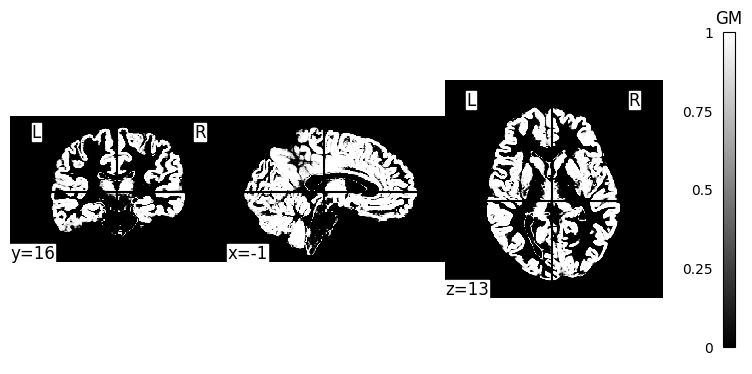

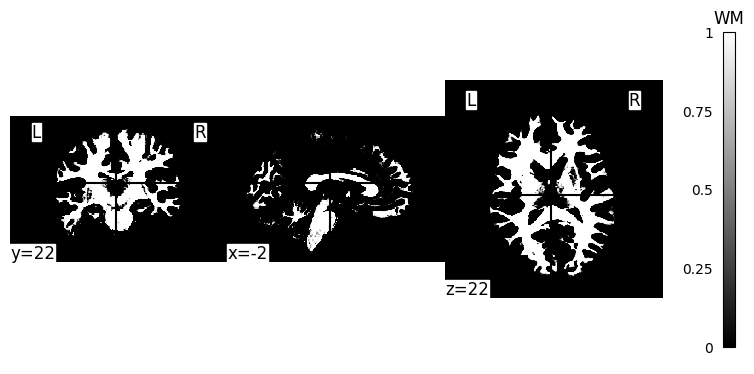

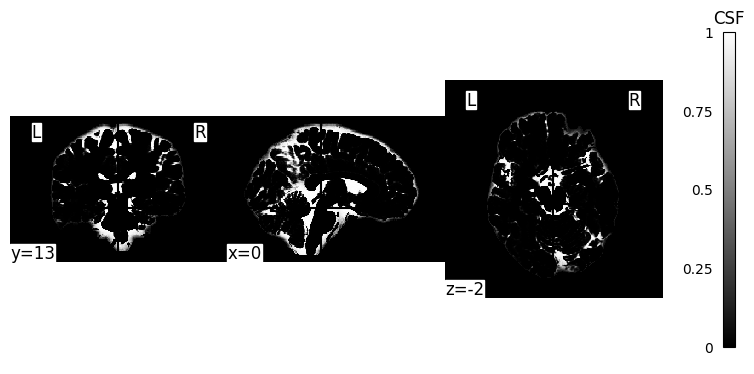

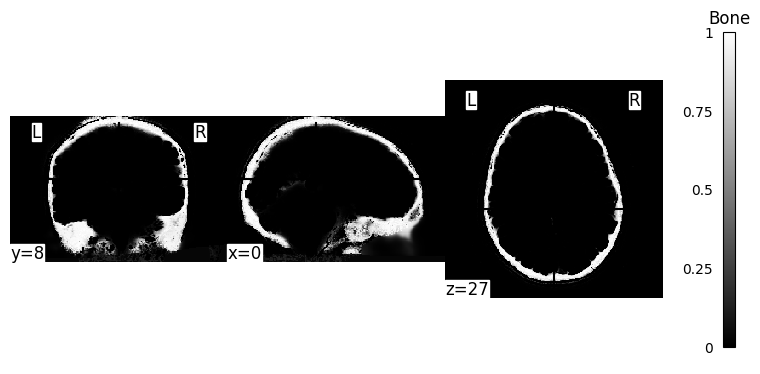

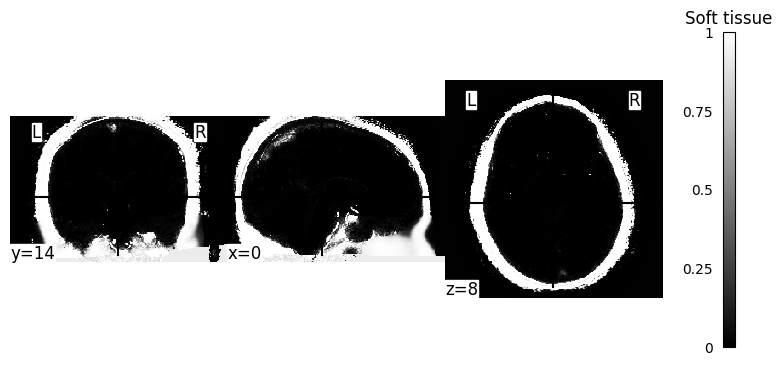

In [20]:
names = ['GM', 'WM', 'CSF', 'Bone', 'Soft tissue']
for i,c in enumerate(glob(cpath)):
    plot_img(load_img(c))
    plt.title(names[i])
    show()

In [25]:
for i,c in enumerate(glob(cpath)):
    print(f"{names[i]}\t:\t{load_img(c).shape}")

GM	:	(256, 256, 124)
WM	:	(256, 256, 124)
CSF	:	(256, 256, 124)
Bone	:	(256, 256, 124)
Soft tissue	:	(256, 256, 124)


In [88]:
wm_probmap, csf_probmap = [load_img(c) for c in glob(cpath)[1:3]]
wm_probmap, csf_probmap

(<nibabel.nifti1.Nifti1Image at 0x15c68a77d10>,
 <nibabel.nifti1.Nifti1Image at 0x15c68a74380>)

In [89]:
mean_fmri = load_img(os.path.join(utils2.DATASET_PATH, 'sub-20131', 'ses-1', 'func', 'wmeanasub-20131_ses-1_task-TAU1_run-1_bold.nii'))
mean_fmri.shape

(79, 95, 79)

In [90]:
load_img(os.path.join(utils2.DATASET_PATH, 'sub-20131', 'ses-1', 'func', 'wmeanasub-20131_ses-1_task-rest_bold.nii')).shape

(79, 95, 79)

In [91]:
run1_fmri = load_img(os.path.join(utils2.DATASET_PATH, 'sub-20131', 'ses-1', 'func', 'wrasub-20131_ses-1_task-TAU1_run-1_bold.nii'))
run2_fmri = load_img(os.path.join(utils2.DATASET_PATH, 'sub-20131', 'ses-1', 'func', 'wrasub-20131_ses-1_task-TAU1_run-2_bold.nii'))
rest_fmri = load_img(os.path.join(utils2.DATASET_PATH, 'sub-20131', 'ses-1', 'func', 'wrasub-20131_ses-1_task-rest_bold.nii'))

In [92]:
def extract_nuisance_timeseries(wm_probmap, csf_probmap, mean_fmri, run1_fmri, run2_fmri, rest_fmri, threshold=0.9):
    wm_mask = math_img(f"img >= {threshold}", img=wm_probmap)
    csf_mask = math_img(f"img >= {threshold}", img=csf_probmap)
    wm_mask_resampled = resample_to_img(
        wm_mask, mean_fmri, interpolation='nearest'
    )
    csf_mask_resampled = resample_to_img(
        csf_mask, mean_fmri, interpolation='nearest'
    )
    wm_masker = NiftiMasker(mask_img=wm_mask_resampled, standardize=False)
    csf_masker = NiftiMasker(mask_img=csf_mask_resampled, standardize=False)

    # 2d matrix (num_timepoints x num_ci_voxels)
    run1_wm_signals = wm_masker.fit_transform(run1_fmri)
    run1_csf_signals = csf_masker.fit_transform(run1_fmri)
    run2_wm_signals = wm_masker.fit_transform(run2_fmri)
    run2_csf_signals = csf_masker.fit_transform(run2_fmri)
    rest_wm_signals = wm_masker.fit_transform(rest_fmri)
    rest_csf_signals = csf_masker.fit_transform(rest_fmri)

    print(run1_wm_signals.shape, run1_csf_signals.shape)

    # reducing to signals to 1D
    run1_wm_mean = run1_wm_signals.mean(axis=1, keepdims=True)
    run1_csf_mean = run1_csf_signals.mean(axis=1, keepdims=True)
    run2_wm_mean = run2_wm_signals.mean(axis=1, keepdims=True)
    run2_csf_mean = run2_csf_signals.mean(axis=1, keepdims=True)
    rest_wm_mean = rest_wm_signals.mean(axis=1, keepdims=True)
    rest_csf_mean = rest_csf_signals.mean(axis=1, keepdims=True)

    print(run1_wm_mean.shape, run1_csf_mean.shape)

    run1_nuisance_df = pd.DataFrame(np.hstack([run1_wm_mean, run1_csf_mean]),
                                    columns=['wm_signal', 'csf_signal']
                                   )
    run2_nuisance_df = pd.DataFrame(np.hstack([run2_wm_mean, run2_csf_mean]),
                                    columns=['wm_signal', 'csf_signal']
                                   )
    rest_nuisance_df = pd.DataFrame(np.hstack([rest_wm_mean, rest_csf_mean]),
                                    columns=['wm_signal', 'csf_signal']
                                   )
    return run1_nuisance_df, run2_nuisance_df, rest_nuisance_df

In [93]:
def extract_small_nuisance_timeseries(bone_probmap, st_probmap, mean_fmri, run1_fmri, run2_fmri, rest_fmri, threshold=0.9):
    bone_mask = math_img(f"img >= {threshold}", img=bone_probmap)
    st_mask = math_img(f"img >= {threshold}", img=st_probmap)
    bone_mask_resampled = resample_to_img(
        bone_mask, mean_fmri, interpolation='nearest'
    )
    st_mask_resampled = resample_to_img(
        st_mask, mean_fmri, interpolation='nearest'
    )
    bone_masker = NiftiMasker(mask_img=bone_mask_resampled, standardize=False)
    st_masker = NiftiMasker(mask_img=st_mask_resampled, standardize=False)

    # 2d matrix (num_timepoints x num_ci_voxels)
    run1_bone_signals = bone_masker.fit_transform(run1_fmri)
    run1_st_signals = st_masker.fit_transform(run1_fmri)
    run2_bone_signals = bone_masker.fit_transform(run2_fmri)
    run2_st_signals = st_masker.fit_transform(run2_fmri)
    rest_bone_signals = bone_masker.fit_transform(rest_fmri)
    rest_st_signals = st_masker.fit_transform(rest_fmri)

    print(run1_bone_signals.shape, run1_st_signals.shape)

    # reducing to signals to 1D
    run1_bone_mean = run1_bone_signals.mean(axis=1, keepdims=True)
    run1_st_mean = run1_st_signals.mean(axis=1, keepdims=True)
    run2_bone_mean = run2_bone_signals.mean(axis=1, keepdims=True)
    run2_st_mean = run2_st_signals.mean(axis=1, keepdims=True)
    rest_bone_mean = rest_bone_signals.mean(axis=1, keepdims=True)
    rest_st_mean = rest_st_signals.mean(axis=1, keepdims=True)

    print(run1_bone_mean.shape, run1_st_mean.shape)

    run1_nuisance_df = pd.DataFrame(np.hstack([run1_bone_mean, run1_st_mean]),
                                    columns=['bone_signal', 'st_signal']
                                   )
    run2_nuisance_df = pd.DataFrame(np.hstack([run2_bone_mean, run2_st_mean]),
                                    columns=['bone_signal', 'st_signal']
                                   )
    rest_nuisance_df = pd.DataFrame(np.hstack([rest_bone_mean, rest_st_mean]),
                                    columns=['bone_signal', 'st_signal']
                                   )
    return run1_nuisance_df, run2_nuisance_df, rest_nuisance_df

In [94]:
run1_nuisance_df, run2_nuisance_df, rest_nuisance_df = extract_nuisance_timeseries(
wm_probmap, csf_probmap, mean_fmri, run1_fmri, run2_fmri, rest_fmri
)
run1_nuisance_df.head()

(184, 46070) (184, 6633)
(184, 1) (184, 1)


,wm_signal,csf_signal
0,4651.823242,3958.954346
1,4448.449219,3736.520996
2,4208.786621,3469.452393
3,4204.133789,3449.968018
4,4151.521484,3392.056152


In [95]:
# run1_nuisance_df = pd.DataFrame(run1_nuisance, columns=['wm_signal', 'csf_signal'])
# run2_nuisance_df = pd.DataFrame(run2_nuisance, columns=['wm_signal', 'csf_signal'])
# rest_nuisance_df = pd.DataFrame(rest_nuisance, columns=['wm_signal', 'csf_signal'])
# run1_nuisance_df.head()

In [96]:
run1_motion = pd.read_table(
    os.path.join(utils2.DATASET_PATH, 'sub-20131', 'ses-1', 'func', 'rp_asub-20131_ses-1_task-TAU1_run-1_bold.txt'), 
    header=None, names=['tx', 'ty', 'tz', 'rx', 'ry', 'rz'], sep='\\s+')
run2_motion = pd.read_table(
    os.path.join(utils2.DATASET_PATH, 'sub-20131', 'ses-1', 'func', 'rp_asub-20131_ses-1_task-TAU1_run-2_bold.txt'), 
    header=None, names=['tx', 'ty', 'tz', 'rx', 'ry', 'rz'], sep='\\s+')
rest_motion = pd.read_table(
    os.path.join(utils2.DATASET_PATH, 'sub-20131', 'ses-1', 'func', 'rp_asub-20131_ses-1_task-rest_bold.txt'), 
    header=None, names=['tx', 'ty', 'tz', 'rx', 'ry', 'rz'], sep='\\s+')

In [97]:
run1_motion.head()

,tx,ty,tz,rx,ry,rz
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.009972,0.007392,-0.032410,-0.000724,-0.000133,-0.000331
2,-0.016057,0.010838,0.029528,-0.001071,-0.000285,-0.000422
3,0.000497,0.015284,0.061122,-0.001177,-0.000827,-0.000260
4,0.013372,0.004116,0.110428,-0.001453,-0.001763,-0.000104


In [98]:
run1_motion.shape

(184, 6)

In [99]:
run1_confounds = pd.concat([run1_motion, run1_nuisance_df], axis=1)
run1_confounds.shape

(184, 8)

In [100]:
run2_confounds = pd.concat([run2_motion, run2_nuisance_df], axis=1)
rest_confounds = pd.concat([rest_motion, rest_nuisance_df], axis=1)

In [101]:
run1_events = pd.read_csv(
    os.path.join(utils2.DATASET_PATH, 'sub-20131', 'ses-1', 'func', 'sub-20131_ses-1_task-TAU1_run-1_events.tsv'),
    sep='\t'
)
run2_events = pd.read_csv(
    os.path.join(utils2.DATASET_PATH, 'sub-20131', 'ses-1', 'func', 'sub-20131_ses-1_task-TAU1_run-2_events.tsv'),
    sep='\t'
)

In [102]:
run1_events.shape

(120, 4)

In [103]:
# Define First-level GLM
fl_glm = FirstLevelModel(
    t_r=utils2.TASK_TR,
    slice_time_ref=utils2.SLICE_TIME_REF,
    smoothing_fwhm=utils2.SMOOTHING,
    hrf_model=utils2.HRF_MODEL,
    drift_model=utils2.DRIFT_MODEL,
    high_pass=utils2.HIGH_PASS,
    standardize=utils2.STANDARDIZE,
    n_jobs=-1,
    verbose=1
)

# fit fl glm
fl_glm.fit([run1_fmri, run2_fmri], 
           events=[run1_events, run2_events],
           confounds=[run1_confounds, run2_confounds]
)   

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x0000015C68A95DC0>

[FirstLevelModel.fit] Computing mask

[FirstLevelModel.fit] Resamping mask

[FirstLevelModel.fit] Finished fit

[FirstLevelModel.fit] Computing run 1 out of 2 runs (go take a coffee, a big one).

[FirstLevelModel.fit] Performing mask computation.

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x0000015C68A95DC0>

[FirstLevelModel.fit] Smoothing images

[FirstLevelModel.fit] Extracting region signals

[FirstLevelModel.fit] Cleaning extracted signals

[FirstLevelModel.fit] Masking took 3 seconds.

[FirstLevelModel.fit] Performing GLM computation.

[FirstLevelModel.fit] GLM took 10 seconds.

[FirstLevelModel.fit] Computing run 2 out of 2 runs (15 seconds remaining).

[FirstLevelModel.fit] Performing mask computation.

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x0000015C384B2AB0>

[FirstLevelModel.fit] Smoothing images

[FirstLevelModel.fit] Extracting region signals

[FirstLevelModel.fit] Cleaning extracted signals

[FirstLevelModel.fit] Masking took 4 seconds.

[FirstLevelModel.fit] Performing GLM computation.

[FirstLevelModel.fit] GLM took 5 seconds.

[FirstLevelModel.fit] Computation of 2 runs done in 25 seconds.

,t_r,2.3
,slice_time_ref,0.0
,hrf_model,'spm'
,drift_model,'cosine'
,high_pass,0.01
,drift_order,1
,fir_delays,None
,min_onset,-24
,mask_img,None
,target_affine,None
,target_shape,None


In [104]:
run1_dm, run2_dm = fl_glm.design_matrices_

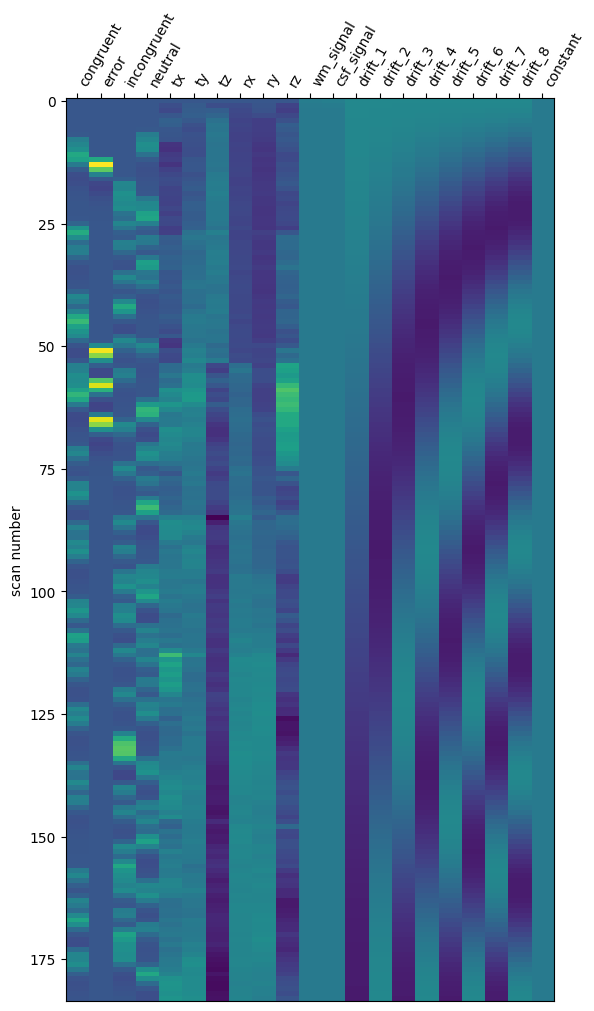

In [105]:
plot_design_matrix(run1_dm)
show()

In [106]:
contrast_outputs = fl_glm.compute_contrast(
    contrast_def=utils2.CONTRASTS['incongruent_vs_congruent'],
    stat_type='t',
    output_type='z_score'
)

[FirstLevelModel.compute_contrast] Computing image from signals

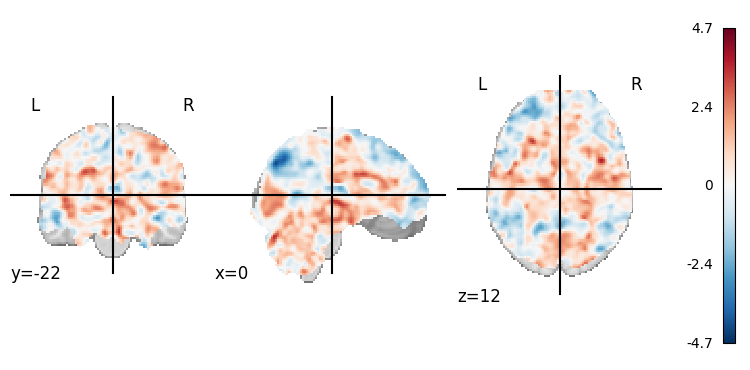

In [107]:
plot_stat_map(contrast_outputs)

In [108]:
# Define First-level GLM
fl_glm2 = FirstLevelModel(
    t_r=utils2.TASK_TR,
    slice_time_ref=utils2.SLICE_TIME_REF,
    smoothing_fwhm=utils2.SMOOTHING,
    hrf_model=utils2.HRF_MODEL,
    drift_model=utils2.DRIFT_MODEL,
    high_pass=utils2.HIGH_PASS,
    standardize=utils2.STANDARDIZE,
    n_jobs=-1,
    verbose=1
)

# fit fl glm
fl_glm2.fit([run1_fmri, run2_fmri], 
           events=[run1_events, run2_events],
           confounds=[run1_motion, run2_motion]
)   

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x0000015C68A95DC0>

[FirstLevelModel.fit] Computing mask

[FirstLevelModel.fit] Resamping mask

[FirstLevelModel.fit] Finished fit

[FirstLevelModel.fit] Computing run 1 out of 2 runs (go take a coffee, a big one).

[FirstLevelModel.fit] Performing mask computation.

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x0000015C68A95DC0>

[FirstLevelModel.fit] Smoothing images

[FirstLevelModel.fit] Extracting region signals

[FirstLevelModel.fit] Cleaning extracted signals

[FirstLevelModel.fit] Masking took 3 seconds.

[FirstLevelModel.fit] Performing GLM computation.

[FirstLevelModel.fit] GLM took 5 seconds.

[FirstLevelModel.fit] Computing run 2 out of 2 runs (9 seconds remaining).

[FirstLevelModel.fit] Performing mask computation.

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x0000015C384B2AB0>

[FirstLevelModel.fit] Smoothing images

[FirstLevelModel.fit] Extracting region signals

[FirstLevelModel.fit] Cleaning extracted signals

[FirstLevelModel.fit] Masking took 4 seconds.

[FirstLevelModel.fit] Performing GLM computation.

[FirstLevelModel.fit] GLM took 5 seconds.

[FirstLevelModel.fit] Computation of 2 runs done in 19 seconds.

,t_r,2.3
,slice_time_ref,0.0
,hrf_model,'spm'
,drift_model,'cosine'
,high_pass,0.01
,drift_order,1
,fir_delays,None
,min_onset,-24
,mask_img,None
,target_affine,None
,target_shape,None


In [109]:
contrast_outputs2 = fl_glm2.compute_contrast(
    contrast_def=utils2.CONTRASTS['incongruent_vs_congruent'],
    stat_type='t',
    output_type='z_score'
)

[FirstLevelModel.compute_contrast] Computing image from signals

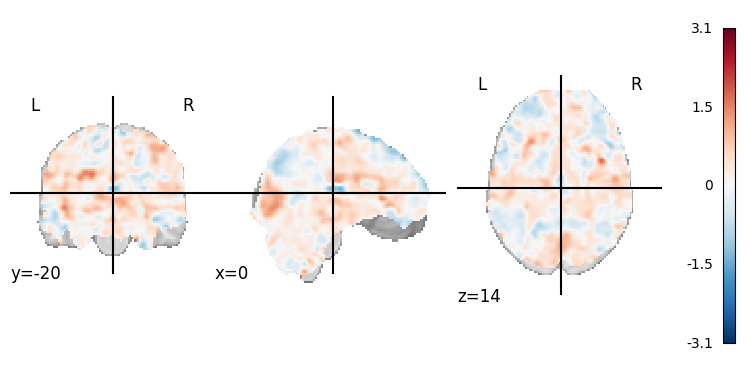

In [110]:
plot_stat_map(contrast_outputs2)

In [111]:
run1_nuisance_df2, run2_nuisance_df2, rest_nuisance_df2 = extract_nuisance_timeseries(
    wm_probmap, csf_probmap, 
    mean_fmri, run1_fmri, run2_fmri, rest_fmri, 
    threshold=0.95
)
run1_nuisance_df2.head()

(184, 43966) (184, 5103)
(184, 1) (184, 1)


,wm_signal,csf_signal
0,4665.762695,4257.186523
1,4462.868652,4018.526367
2,4223.565430,3733.592773
3,4218.857422,3711.562500
4,4166.338379,3651.878418


In [112]:
run1_confounds2= pd.concat([run1_motion, run1_nuisance_df2], axis=1)
run2_confounds2= pd.concat([run2_motion, run2_nuisance_df2], axis=1)
rest_confounds2= pd.concat([rest_motion, rest_nuisance_df2], axis=1)

In [113]:
# Define First-level GLM
fl_glm3 = FirstLevelModel(
    t_r=utils2.TASK_TR,
    slice_time_ref=utils2.SLICE_TIME_REF,
    smoothing_fwhm=utils2.SMOOTHING,
    hrf_model=utils2.HRF_MODEL,
    drift_model=utils2.DRIFT_MODEL,
    high_pass=utils2.HIGH_PASS,
    standardize=utils2.STANDARDIZE,
    n_jobs=-1,
    verbose=1
)

# fit fl glm
fl_glm3.fit([run1_fmri, run2_fmri], 
           events=[run1_events, run2_events],
           confounds=[run1_confounds2, run2_confounds2]
)   

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x0000015C68A95DC0>

[FirstLevelModel.fit] Computing mask

[FirstLevelModel.fit] Resamping mask

[FirstLevelModel.fit] Finished fit

[FirstLevelModel.fit] Computing run 1 out of 2 runs (go take a coffee, a big one).

[FirstLevelModel.fit] Performing mask computation.

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x0000015C68A95DC0>

[FirstLevelModel.fit] Smoothing images

[FirstLevelModel.fit] Extracting region signals

[FirstLevelModel.fit] Cleaning extracted signals

[FirstLevelModel.fit] Masking took 4 seconds.

[FirstLevelModel.fit] Performing GLM computation.

[FirstLevelModel.fit] GLM took 5 seconds.

[FirstLevelModel.fit] Computing run 2 out of 2 runs (9 seconds remaining).

[FirstLevelModel.fit] Performing mask computation.

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x0000015C384B2AB0>

[FirstLevelModel.fit] Smoothing images

[FirstLevelModel.fit] Extracting region signals

[FirstLevelModel.fit] Cleaning extracted signals

[FirstLevelModel.fit] Masking took 4 seconds.

[FirstLevelModel.fit] Performing GLM computation.

[FirstLevelModel.fit] GLM took 5 seconds.

[FirstLevelModel.fit] Computation of 2 runs done in 20 seconds.

,t_r,2.3
,slice_time_ref,0.0
,hrf_model,'spm'
,drift_model,'cosine'
,high_pass,0.01
,drift_order,1
,fir_delays,None
,min_onset,-24
,mask_img,None
,target_affine,None
,target_shape,None


In [114]:
contrast_outputs3 = fl_glm3.compute_contrast(
    contrast_def=utils2.CONTRASTS['incongruent_vs_congruent'],
    stat_type='t',
    output_type='z_score'
)

[FirstLevelModel.compute_contrast] Computing image from signals

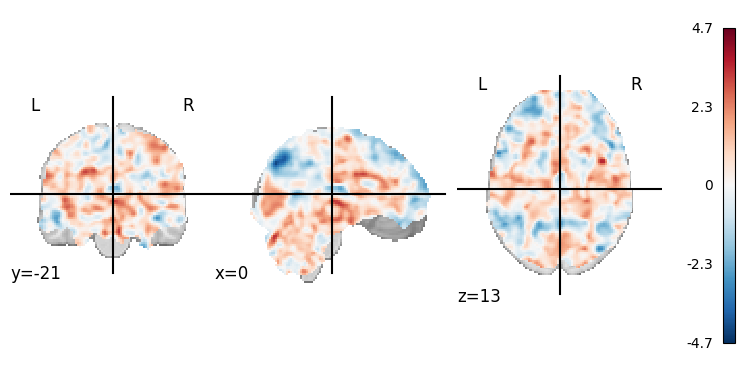

In [115]:
plot_stat_map(contrast_outputs3)

In [121]:
bone_probmap, st_probmap = [load_img(c) for c in glob(cpath)[3:]]

In [122]:
run1_nuisance_df22, run2_nuisance_df22, rest_nuisance_df22 = extract_small_nuisance_timeseries(
    bone_probmap, st_probmap, 
    mean_fmri, run1_fmri, run2_fmri, rest_fmri, 
    threshold=0.95
)
run1_nuisance_df22.head()

(184, 17867) (184, 102603)
(184, 1) (184, 1)


,bone_signal,st_signal
0,3241.727783,1930.967529
1,3070.571045,1814.821533
2,2886.402588,1704.335815
3,2877.614502,1696.070435
4,2837.047363,1674.163574


In [123]:
run1_confounds3= pd.concat([run1_motion, run1_nuisance_df2, run1_nuisance_df22], axis=1)
run2_confounds3= pd.concat([run2_motion, run2_nuisance_df2, run2_nuisance_df22], axis=1)
rest_confounds3= pd.concat([rest_motion, rest_nuisance_df2, rest_nuisance_df22], axis=1)

In [124]:
# Define First-level GLM
fl_glm4 = FirstLevelModel(
    t_r=utils2.TASK_TR,
    slice_time_ref=utils2.SLICE_TIME_REF,
    smoothing_fwhm=utils2.SMOOTHING,
    hrf_model=utils2.HRF_MODEL,
    drift_model=utils2.DRIFT_MODEL,
    high_pass=utils2.HIGH_PASS,
    standardize=utils2.STANDARDIZE,
    n_jobs=-1,
    verbose=1
)

# fit fl glm
fl_glm4.fit([run1_fmri, run2_fmri], 
           events=[run1_events, run2_events],
           confounds=[run1_confounds3, run2_confounds3]
)   

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x0000015C68A95DC0>

[FirstLevelModel.fit] Computing mask

[FirstLevelModel.fit] Resamping mask

[FirstLevelModel.fit] Finished fit

[FirstLevelModel.fit] Computing run 1 out of 2 runs (go take a coffee, a big one).

[FirstLevelModel.fit] Performing mask computation.

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x0000015C68A95DC0>

[FirstLevelModel.fit] Smoothing images

[FirstLevelModel.fit] Extracting region signals

[FirstLevelModel.fit] Cleaning extracted signals

[FirstLevelModel.fit] Masking took 4 seconds.

[FirstLevelModel.fit] Performing GLM computation.

[FirstLevelModel.fit] GLM took 5 seconds.

[FirstLevelModel.fit] Computing run 2 out of 2 runs (9 seconds remaining).

[FirstLevelModel.fit] Performing mask computation.

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x0000015C384B2AB0>

[FirstLevelModel.fit] Smoothing images

[FirstLevelModel.fit] Extracting region signals

[FirstLevelModel.fit] Cleaning extracted signals

[FirstLevelModel.fit] Masking took 4 seconds.

[FirstLevelModel.fit] Performing GLM computation.

[FirstLevelModel.fit] GLM took 6 seconds.

[FirstLevelModel.fit] Computation of 2 runs done in 20 seconds.

,t_r,2.3
,slice_time_ref,0.0
,hrf_model,'spm'
,drift_model,'cosine'
,high_pass,0.01
,drift_order,1
,fir_delays,None
,min_onset,-24
,mask_img,None
,target_affine,None
,target_shape,None


In [125]:
contrast_outputs4 = fl_glm4.compute_contrast(
    contrast_def=utils2.CONTRASTS['incongruent_vs_congruent'],
    stat_type='t',
    output_type='z_score'
)

[FirstLevelModel.compute_contrast] Computing image from signals

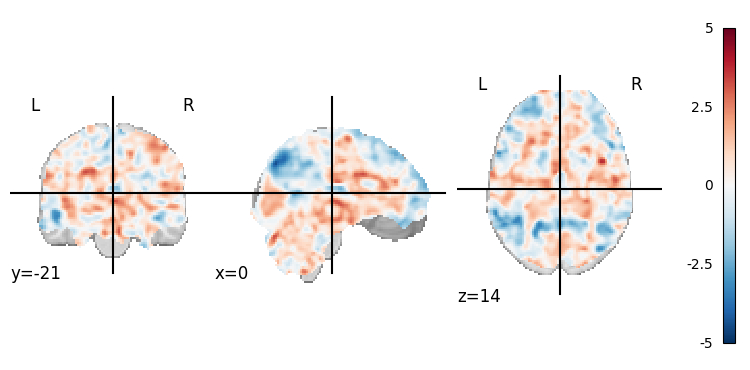

In [126]:
plot_stat_map(contrast_outputs4)

<Axes: label='conditions', ylabel='scan number'>

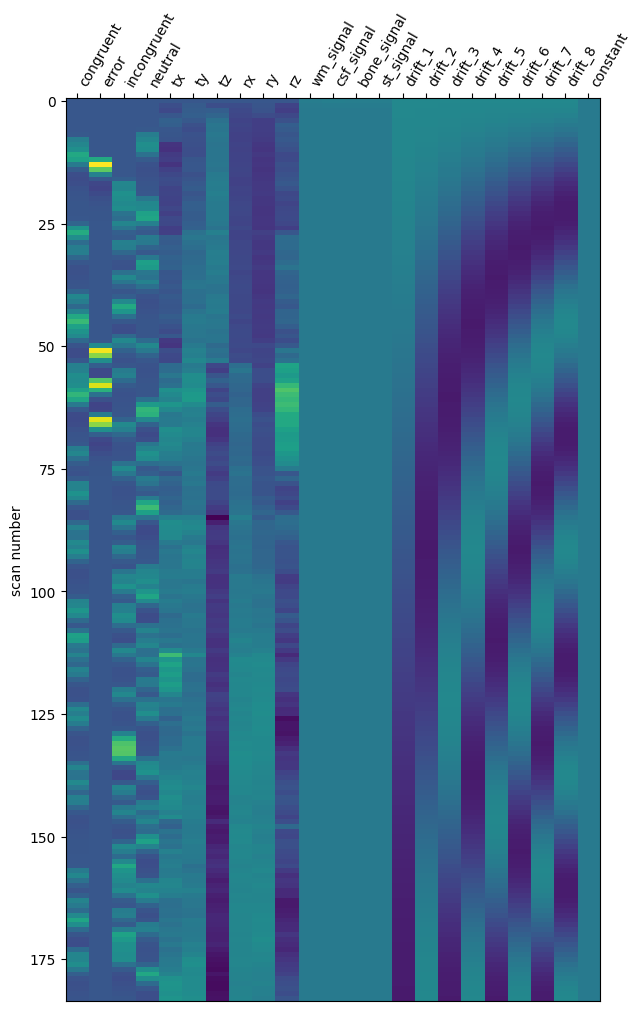

In [127]:
plot_design_matrix(fl_glm4.design_matrices_[0])

In [131]:
run1_confounds4 = run1_confounds3.copy()
run1_confounds4.drop(columns=['bone_signal'], inplace=True)

run2_confounds4 = run2_confounds3.copy()
run2_confounds4.drop(columns=['bone_signal'], inplace=True)

rest_confounds4 = rest_confounds3.copy()
rest_confounds4.drop(columns=['bone_signal'], inplace=True)

In [132]:
run1_confounds4.head()

,tx,ty,tz,rx,ry,rz,wm_signal,csf_signal,st_signal
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4665.762695,4257.186523,1930.967529
1,-0.009972,0.007392,-0.032410,-0.000724,-0.000133,-0.000331,4462.868652,4018.526367,1814.821533
2,-0.016057,0.010838,0.029528,-0.001071,-0.000285,-0.000422,4223.565430,3733.592773,1704.335815
3,0.000497,0.015284,0.061122,-0.001177,-0.000827,-0.000260,4218.857422,3711.562500,1696.070435
4,0.013372,0.004116,0.110428,-0.001453,-0.001763,-0.000104,4166.338379,3651.878418,1674.163574


In [133]:
# Define First-level GLM
fl_glm5 = FirstLevelModel(
    t_r=utils2.TASK_TR,
    slice_time_ref=utils2.SLICE_TIME_REF,
    smoothing_fwhm=utils2.SMOOTHING,
    hrf_model=utils2.HRF_MODEL,
    drift_model=utils2.DRIFT_MODEL,
    high_pass=utils2.HIGH_PASS,
    standardize=utils2.STANDARDIZE,
    n_jobs=-1,
    verbose=1
)

# fit fl glm
fl_glm5.fit([run1_fmri, run2_fmri], 
           events=[run1_events, run2_events],
           confounds=[run1_confounds4, run2_confounds4]
)   

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x0000015C68A95DC0>

[FirstLevelModel.fit] Computing mask

[FirstLevelModel.fit] Resamping mask

[FirstLevelModel.fit] Finished fit

[FirstLevelModel.fit] Computing run 1 out of 2 runs (go take a coffee, a big one).

[FirstLevelModel.fit] Performing mask computation.

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x0000015C68A95DC0>

[FirstLevelModel.fit] Smoothing images

[FirstLevelModel.fit] Extracting region signals

[FirstLevelModel.fit] Cleaning extracted signals

[FirstLevelModel.fit] Masking took 4 seconds.

[FirstLevelModel.fit] Performing GLM computation.

[FirstLevelModel.fit] GLM took 12 seconds.

[FirstLevelModel.fit] Computing run 2 out of 2 runs (17 seconds remaining).

[FirstLevelModel.fit] Performing mask computation.

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x0000015C384B2AB0>

[FirstLevelModel.fit] Smoothing images

[FirstLevelModel.fit] Extracting region signals

[FirstLevelModel.fit] Cleaning extracted signals

[FirstLevelModel.fit] Masking took 4 seconds.

[FirstLevelModel.fit] Performing GLM computation.

[FirstLevelModel.fit] GLM took 5 seconds.

[FirstLevelModel.fit] Computation of 2 runs done in 27 seconds.

,t_r,2.3
,slice_time_ref,0.0
,hrf_model,'spm'
,drift_model,'cosine'
,high_pass,0.01
,drift_order,1
,fir_delays,None
,min_onset,-24
,mask_img,None
,target_affine,None
,target_shape,None


In [134]:
contrast_outputs5 = fl_glm5.compute_contrast(
    contrast_def=utils2.CONTRASTS['incongruent_vs_congruent'],
    stat_type='t',
    output_type='z_score'
)

[FirstLevelModel.compute_contrast] Computing image from signals

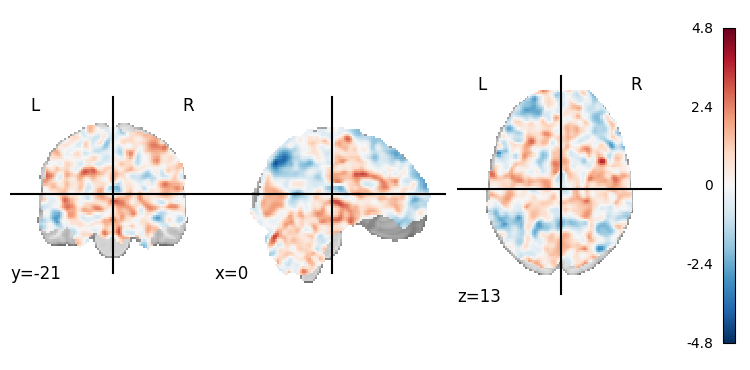

In [135]:
plot_stat_map(contrast_outputs5)

<Axes: label='conditions', ylabel='scan number'>

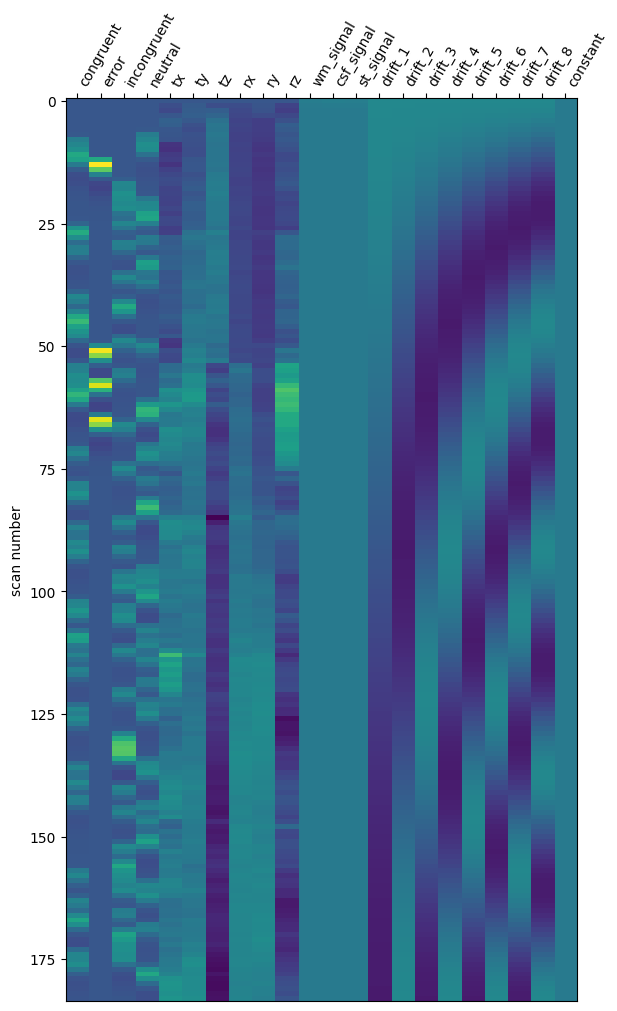

In [136]:
plot_design_matrix(fl_glm5.design_matrices_[0])